In [2]:
import requests
import urllib.request
import json
import shutil
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from sklearn.metrics import adjusted_rand_score
import hdbscan
import umap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SPECTRAL_COLS = ['dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']
ALL_COLS = TIMEDOM_COLS + SPECTRAL_COLS

print('Imports OK')
print(f'Using {len(TIMEDOM_COLS)} time-domain features for stability clustering')

Imports OK
Using 6 time-domain features for stability clustering


In [3]:
# ============================================================
# HELPERS
# ============================================================

def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()


def baseline_delta(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))


def spectral_features_fixed(series):
    """Spectral features on original series — NO interpolation."""
    s = zscore_normalize(np.asarray(series, dtype=float))
    n = len(s)
    fft_vals = np.fft.rfft(s)
    power    = np.abs(fft_vals) ** 2
    freqs    = np.fft.rfftfreq(n)
    power_ac = power[1:]
    freqs_ac = freqs[1:]
    total_ac = power_ac.sum() if power_ac.sum() > 0 else 1.0
    dom_idx  = np.argmax(power)
    dom_freq = float(freqs[dom_idx])
    p_norm = power_ac / total_ac
    p_norm = p_norm[p_norm > 0]
    sp_ent = float(-np.sum(p_norm * np.log(p_norm)))
    sp_ent /= np.log(len(power_ac)) if len(power_ac) > 1 else 1.0
    n_ac   = len(freqs_ac)
    low_end = int(n_ac * 0.20)
    mid_end = int(n_ac * 0.60)
    p_low  = float(power_ac[:low_end].sum()  / total_ac)
    p_mid  = float(power_ac[low_end:mid_end].sum() / total_ac)
    p_high = float(power_ac[mid_end:].sum()  / total_ac)
    return {'dominant_freq': dom_freq, 'spectral_entropy': sp_ent,
            'power_low': p_low, 'power_mid': p_mid, 'power_high': p_high}


def extract_all_features(series):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n   = len(arr)
    t   = np.arange(n)
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    zc   = float(np.sum(np.diff(np.sign(arr)) != 0) / n)
    slope = float(stats.linregress(t, arr).slope)
    td = {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': zc,
        'slope':          slope,
        'baseline_delta': baseline_delta(arr),
    }
    sp = spectral_features_fixed(arr)
    return {**td, **sp}


print('Helpers OK')

Helpers OK


In [4]:
# ============================================================
# DATASET 1: COVID (first + second wave)
# ============================================================
dest = RAW_DIR / 'owid_covid.csv'
if not dest.exists():
    print('Downloading OWID COVID...')
    r = requests.get('https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv', stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(8192): f.write(chunk)
df_raw = pd.read_csv(dest, usecols=['location','date','new_cases_smoothed_per_million','continent'], parse_dates=['date'])
df_covid = df_raw.dropna(subset=['continent']).rename(columns={'new_cases_smoothed_per_million':'cases_pm'})

def extract_first_wave(series, max_days=180, min_days=30):
    s = series.fillna(0).values
    starts = np.where(s > 0.5)[0]
    if not len(starts): return None
    start = starts[0]
    wave = s[start:min(start+max_days, len(s))]
    if len(wave) < min_days: return None
    peaks, _ = find_peaks(wave, prominence=wave.max()*0.2)
    if not len(peaks): return None
    wave = wave[:min(peaks[0]+60, len(wave))]
    return wave if len(wave) >= min_days else None

def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max()*0.15, distance=45)
    if len(peaks) < 2: return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    wave = s[start:min(peaks[1]+60, len(s))]
    return wave if len(wave) >= min_days else None

records = []
for country, grp in df_covid.groupby('location'):
    grp = grp.sort_values('date')
    for fn, ds in [(extract_first_wave,'covid_first_wave'), (extract_second_wave,'covid_second_wave')]:
        w = fn(grp['cases_pm'])
        if w is not None:
            feats = extract_all_features(w)
            feats.update({'country': country, 'dataset': ds, 'n_points': len(w)})
            records.append(feats)
df_covid_all = pd.DataFrame(records)
print(df_covid_all['dataset'].value_counts().to_dict())

{'covid_second_wave': 209, 'covid_first_wave': 202}


In [6]:
# ============================================================
# DATASET 2: Sunspot cycles
# ============================================================
dest = RAW_DIR / 'sunspot_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv').content)
df_ss = pd.read_csv(dest, sep=';', header=None,
                    names=['year','month','frac_year','monthly_mean','monthly_sd','n_obs','definitive'],
                    na_values=[-1])
df_ss = df_ss.dropna(subset=['monthly_mean'])
df_ss['smooth'] = df_ss['monthly_mean'].rolling(13, center=True).mean()
series_full = df_ss['smooth'].bfill().ffill().values
smoothed = pd.Series(series_full).rolling(25, center=True).mean().bfill().ffill().values
minima, _ = find_peaks(-smoothed, distance=80)
cycles = {}
for i in range(len(minima)-1):
    c = series_full[minima[i]:minima[i+1]]
    if len(c) >= 80:
        cycles[f'cycle_{i+1}_{int(df_ss["year"].iloc[minima[i]])}'] = c
records = []
for name, c in cycles.items():
    feats = extract_all_features(c)
    feats.update({'country': name, 'dataset': 'sunspot_cycle', 'n_points': len(c)})
    records.append(feats)
df_ss_all = pd.DataFrame(records)
print(f'Sunspot: {len(df_ss_all)} cycles')

Sunspot: 24 cycles


In [7]:
# ============================================================
# DATASET 3: Lynx-hare
# ============================================================
df_lh = pd.read_csv(Path('../datasets/lynx_hare/lynx_hare.csv'))
year_col = [c for c in df_lh.columns if c.lower()=='year'][0]
species_cols = [c for c in df_lh.columns if c.lower()!='year']
window_size = 10
series_dict = {}
for sp in species_cols:
    full = df_lh[sp].values.astype(float)
    series_dict[f'{sp}_full'] = full
    for start in range(len(full)-window_size+1):
        series_dict[f'{sp}_w{start}_{df_lh[year_col].iloc[start]}'] = full[start:start+window_size]
records = []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': 'lynx_hare', 'n_points': len(s)})
    records.append(feats)
df_lh_all = pd.DataFrame(records)
print(f'Lynx-hare: {len(df_lh_all)}')

Lynx-hare: 26


In [8]:
# ============================================================
# DATASET 4: Keeling CO2 (seasonal + trend)
# ============================================================
dest = RAW_DIR / 'keeling_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv').content)
co2 = pd.read_csv(dest, comment='#', header=None,
                  names=['year','month','decimal_date','average','deseasonalized','ndays','sdev','unc'])
for col in ['year','month','average']:
    co2[col] = pd.to_numeric(co2[col], errors='coerce')
co2 = co2.dropna(subset=['year','month','average'])
co2 = co2[co2['average']>0].copy()
co2.index = pd.to_datetime({'year':co2['year'].astype(int),'month':co2['month'].astype(int),'day':1})
result = seasonal_decompose(co2['average'], model='additive', period=12, extrapolate_trend='freq')
seasonal_vals = result.seasonal.dropna().values
trend_vals    = result.trend.dropna().values
start_year    = co2.index.min().year
series_dict = {}
for i in range(len(seasonal_vals)//12):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg)==12: series_dict[f'keeling_seasonal_{start_year+i}'] = seg
for i in range(0, len(trend_vals)-120, 12):
    series_dict[f'keeling_trend_{start_year+i//12}'] = trend_vals[i:i+120]
records = []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name,
                  'dataset': 'keeling_seasonal' if 'seasonal' in name else 'keeling_trend',
                  'n_points': len(s)})
    records.append(feats)
df_k_all = pd.DataFrame(records)
print(df_k_all['dataset'].value_counts().to_dict())

{'keeling_seasonal': 68, 'keeling_trend': 58}


In [9]:
# ============================================================
# DATASET 5: Global temperature anomaly
# ============================================================
dest = RAW_DIR / 'temperature_anomaly.csv'
if not dest.exists():
    print('Downloading Berkeley Earth temperature...')
    r = requests.get('https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_summary.txt',
                     headers={'User-Agent':'Mozilla/5.0'}, timeout=30)
    r.raise_for_status()
    dest.write_bytes(r.content)
with open(dest) as f: raw = f.read()
if raw.lstrip().startswith('%'):
    rows = []
    for line in raw.splitlines():
        if line.strip() and not line.strip().startswith('%'):
            parts = line.split()
            if len(parts)>=2:
                try: rows.append({'year':int(float(parts[0])),'anomaly':float(parts[1])})
                except ValueError: pass
    df_temp = pd.DataFrame(rows).dropna()
else:
    lines = raw.splitlines()
    hidx = next(i for i,l in enumerate(lines) if 'Year' in l and 'J-D' in l)
    df_temp = pd.read_csv(dest, skiprows=hidx, na_values=['***','****'])
    df_temp = df_temp[['Year','J-D']].rename(columns={'Year':'year','J-D':'anomaly'})
    df_temp['year'] = pd.to_numeric(df_temp['year'],errors='coerce')
    df_temp['anomaly'] = pd.to_numeric(df_temp['anomaly'],errors='coerce')
    df_temp = df_temp.dropna()
    df_temp['year'] = df_temp['year'].astype(int)
values = df_temp['anomaly'].values
years  = df_temp['year'].values
window, step = 20, 5
records = []
for i in range(0, len(values)-window, step):
    s = values[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'temp_{years[i]}','dataset':'temperature','n_points':len(s)})
    records.append(feats)
df_temp_all = pd.DataFrame(records)
print(f'Temperature: {len(df_temp_all)} windows')

Temperature: 31 windows


In [10]:
# ============================================================
# DATASET 6: ECG (requires ECGFiveDays.zip in data/raw/)
# ============================================================
dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'
if dest_dir.exists() and list(dest_dir.rglob('*.ts')):
    print(f'Cached: {dest_dir}')
elif dest_zip.exists():
    if dest_dir.exists(): shutil.rmtree(dest_dir)
    with zipfile.ZipFile(dest_zip) as z: z.extractall(dest_dir)
    print('Extracted from zip')
else:
    raise RuntimeError('ECGFiveDays.zip not found — place in data/raw/')
ts_files = list(dest_dir.rglob('*.ts'))

def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.lower()=='@data': in_data=True; continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':',1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    try: values=[float(x) for x in parts[:-1]]; label=parts[-1]
                    except (ValueError,IndexError): continue
                if values: series_list.append(np.array(values)); labels.append(label.strip())
    return series_list, labels

all_series, all_labels = [], []
for f in ts_files:
    s, l = parse_ts_file(f)
    all_series.extend(s); all_labels.extend(l)
records = []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    feats = extract_all_features(s)
    feats.update({'country':f'ecg_{i}_c{label}','dataset':'ecg','n_points':len(s)})
    records.append(feats)
df_ecg_all = pd.DataFrame(records)
print(f'ECG: {len(df_ecg_all)} segments  kurtosis={df_ecg_all["kurtosis"].mean():.3f}')

Cached: ../data/raw/ECGFiveDays
ECG: 884 segments  kurtosis=15.165


In [11]:
# ============================================================
# DATASET 7: Streamflow (USGS)
# ============================================================
STATIONS = {
    '01350000':'mohawk_ny',    '01427207':'delaware_ny', '01491000':'choptank_md',
    '02087500':'neuse_nc',     '02339500':'flint_ga',    '03049000':'allegheny_pa',
    '03611500':'ohio_il',      '05054000':'red_nd',      '05378500':'mississippi_mn',
    '05420500':'mississippi_ia','06289000':'bighorn_mt', '06600000':'missouri_ia',
    '07022000':'mississippi_mo','07289000':'mississippi_ms','08220000':'riogrande_co',
    '09180000':'colorado_ut',  '09380000':'colorado_az', '11530000':'klamath_ca',
    '12040000':'queets_wa',    '12374250':'clearwater_id','14105700':'columbia_or',
    '14179000':'willamette_or','06354000':'cannonball_nd','02479155':'escatawpa_ms',
    '01096500':'nashua_ma',
}

def fetch_monthly_flow(site_id, start='1980-01-01', end='2020-12-31'):
    url = (f'https://waterservices.usgs.gov/nwis/dv/?format=json'
           f'&sites={site_id}&parameterCd=00060&statCd=00003&startDT={start}&endDT={end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=45) as resp:
            data = json.loads(resp.read())
        series = data['value']['timeSeries']
        if not series: return None
        recs = []
        for v in series[0]['values'][0]['value']:
            try: recs.append({'date':pd.Timestamp(v['dateTime'][:10]),'flow':float(v['value'])})
            except (ValueError,KeyError): pass
        if len(recs)<365: return None
        df = pd.DataFrame(recs).set_index('date')
        monthly = df['flow'].resample('MS').mean().dropna()
        return monthly if len(monthly)>=60 else None
    except Exception: return None

print(f'Fetching {len(STATIONS)} USGS stations...')
flows = {}
for site_id, name in STATIONS.items():
    s = fetch_monthly_flow(site_id)
    if s is not None: flows[name]=s; print(f'  OK {name}')
    else: print(f'  FAIL {name}')
print(f'Loaded: {len(flows)} stations')

records = []
for name, series in flows.items():
    log_flow = np.log1p(series.values.astype(float))
    feats = extract_all_features(log_flow)
    feats.update({'country':name,'dataset':'streamflow','n_points':len(log_flow)})
    records.append(feats)
df_sf_all = pd.DataFrame(records)
print(f'Streamflow: {len(df_sf_all)} stations  dom_freq={df_sf_all["dominant_freq"].mean():.4f}')

Fetching 25 USGS stations...
  OK mohawk_ny
  OK delaware_ny
  OK choptank_md
  OK neuse_nc
  OK flint_ga
  OK allegheny_pa
  OK ohio_il
  OK red_nd
  OK mississippi_mn
  OK mississippi_ia
  OK bighorn_mt
  OK missouri_ia
  OK mississippi_mo
  OK mississippi_ms
  OK riogrande_co
  OK colorado_ut
  OK colorado_az
  OK klamath_ca
  FAIL queets_wa
  OK clearwater_id
  OK columbia_or
  OK willamette_or
  OK cannonball_nd
  OK escatawpa_ms
  OK nashua_ma
Loaded: 24 stations
Streamflow: 24 stations  dom_freq=0.0799


In [12]:
# ============================================================
# DATASET 8: Global Mean Sea Level (Phase 1b — nb15)
# ============================================================
dest = RAW_DIR / 'sea_level_nasa.csv'
if dest.exists(): dest.unlink()

urls = [
    'https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelRise/slr/slr_sla_gbl_keep_all_66.csv',
    'https://sealevel.colorado.edu/files/current/sl_ns_global.txt',
]
content = None
for url in urls:
    try:
        print(f'Trying {url[:50]}...')
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        if b'<!' not in r.content[:20]:
            content = r.content
            print('OK')
            break
    except Exception as e:
        print(f'  failed: {e}')

if content is None:
    raise RuntimeError('Sea level: all URLs failed')
dest.write_bytes(content)

df_sl = pd.read_csv(dest, comment='#')
mission_cols = [c for c in df_sl.columns if c != 'year']
df_sl['gmsl'] = df_sl[mission_cols].mean(axis=1, skipna=True)
df_sl = df_sl[['year', 'gmsl']].dropna().rename(columns={'year': 'year_frac'})
df_sl = df_sl.sort_values('year_frac').reset_index(drop=True)

values_sl = df_sl['gmsl'].values
year_fracs = df_sl['year_frac'].values
window, step = 120, 12  # 10-year windows, 1-year step
records = []
for i in range(0, len(values_sl) - window, step):
    s = values_sl[i:i+window]
    feats = extract_all_features(s)
    yr = int(year_fracs[i])
    feats.update({'country': f'sl_{yr}', 'dataset': 'sea_level', 'n_points': len(s)})
    records.append(feats)
df_sl_all = pd.DataFrame(records)
print(f'Sea level: {len(df_sl_all)} windows')

Trying https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelR...
OK
Sea level: 120 windows


In [13]:
# ============================================================
# DATASET 9: ENSO ONI (Phase 1b — nb16)
# ============================================================
dest = RAW_DIR / 'oni_enso.txt'
if not dest.exists():
    print('Downloading NOAA ONI...')
    r = requests.get(
        'https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt',
        headers={'User-Agent': 'Mozilla/5.0'}, timeout=30
    )
    r.raise_for_status()
    dest.write_bytes(r.content)

rows = []
with open(dest) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('SEAS'): continue
        parts = line.split()
        if len(parts) >= 4:
            try:
                rows.append({'year': int(parts[1]), 'oni': float(parts[3])})
            except (ValueError, IndexError): pass
df_oni = pd.DataFrame(rows).dropna()

values_oni = df_oni['oni'].values
window, step = 36, 6  # 3-year windows, 6-month step
records = []
for i in range(0, len(values_oni) - window, step):
    s = values_oni[i:i+window]
    feats = extract_all_features(s)
    yr = df_oni['year'].iloc[i] if i < len(df_oni) else ''
    feats.update({'country': f'oni_{yr}', 'dataset': 'enso_oni', 'n_points': len(s)})
    records.append(feats)
df_oni_all = pd.DataFrame(records)
print(f'ENSO ONI: {len(df_oni_all)} windows')

ENSO ONI: 147 windows


In [14]:
# ============================================================
# DATASET 10: VIX (Phase 1b — nb17)
# ============================================================
dest = RAW_DIR / 'vix_fred.csv'
if dest.exists(): dest.unlink()

urls = [
    ('cboe-cdn', 'https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX_History.csv'),
    ('cboe-www', 'https://www.cboe.com/publish/ScheduledTask/MktData/datahouse/vixcurrent.csv'),
]
for name, url in urls:
    try:
        print(f'Trying {name}...')
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=60)
        r.raise_for_status()
        if b'<!DOCTYPE' not in r.content[:200] and len(r.content) > 100:
            dest.write_bytes(r.content)
            print(f'OK ({len(r.content):,} bytes)')
            break
    except Exception as e:
        print(f'  failed: {e}')
else:
    raise RuntimeError('All VIX sources failed')

df_vix = pd.read_csv(dest, parse_dates=['DATE'], dayfirst=False)
df_vix = df_vix[['DATE','CLOSE']].rename(columns={'DATE':'date','CLOSE':'vix'}).dropna()
df_vix = df_vix.set_index('date').resample('MS').mean().dropna().reset_index()
values_vix = df_vix['vix'].values

window, step = 24, 3  # 24-month windows, 3-month step
records = []
for i in range(0, len(values_vix) - window, step):
    s = values_vix[i:i+window]
    feats = extract_all_features(s)
    yr = df_vix['date'].iloc[i].year
    feats.update({'country': f'vix_{yr}_{i}', 'dataset': 'vix', 'n_points': len(s)})
    records.append(feats)
df_vix_all = pd.DataFrame(records)
print(f'VIX: {len(df_vix_all)} windows')

Trying cboe-cdn...
OK (466,495 bytes)
VIX: 137 windows


In [15]:
# ============================================================
# COMBINE ALL DATASETS
# ============================================================
df_all = pd.concat([
    df_covid_all, df_ss_all, df_lh_all, df_k_all,
    df_temp_all, df_ecg_all, df_sf_all,
    df_sl_all, df_oni_all, df_vix_all
], ignore_index=True)
df_all = df_all.dropna(subset=ALL_COLS).copy()

DATASETS = sorted(df_all['dataset'].unique())
ORIG_9 = ['covid_first_wave', 'covid_second_wave', 'ecg', 'keeling_seasonal',
           'keeling_trend', 'lynx_hare', 'streamflow', 'sunspot_cycle', 'temperature']
PHASE1B = ['enso_oni', 'sea_level', 'vix']

print(f'Total instances: {len(df_all)}')
print()
print('=== Instance counts ===')
for ds in DATASETS:
    tag = '(orig)' if ds in ORIG_9 else '(1b)  '
    print(f'  {tag} {ds:25s}: {(df_all["dataset"]==ds).sum()}')

Total instances: 1930

=== Instance counts ===
  (orig) covid_first_wave         : 202
  (orig) covid_second_wave        : 209
  (orig) ecg                      : 884
  (1b)   enso_oni                 : 147
  (orig) keeling_seasonal         : 68
  (orig) keeling_trend            : 58
  (orig) lynx_hare                : 26
  (1b)   sea_level                : 120
  (orig) streamflow               : 24
  (orig) sunspot_cycle            : 24
  (orig) temperature              : 31
  (1b)   vix                      : 137


## Pre-run predictions — Phase 1c stability test

*Written before running the parameter sweep.*

**Grid:** `min_cluster_size` ∈ [4, 6, 8, 12, 16] × `min_samples` ∈ [2, 3, 5] → 15 parameter combinations.

**Stability score definition:** % of runs (out of 15) where the dataset's majority-cluster placement captures ≥50% of its instances (i.e., it is not mostly noise).

| Dataset | Predicted stability | Predicted label | Reasoning |
|---|---|---|---|
| keeling_seasonal | 100% | GRANITE | Spectrally pure; isolated in every frame in nb05–17 |
| keeling_trend | 100% | GRANITE | Highest lag1_autocorr in corpus; always isolated |
| ecg | ~100% | GRANITE | kurtosis=15.165 — extreme outlier, no other dataset near it |
| covid_first_wave | ~80% | ROBUST | Right-skewed burst; reliable cluster, occasional noise at large min_cluster_size |
| covid_second_wave | ~80% | ROBUST | Usually pairs with first wave |
| lynx_hare | ~60% | MODERATE | Moderate dynamics; pairs with streamflow but may drift |
| streamflow | ~60% | MODERATE | Paired with lynx_hare; station-level variance may hurt |
| temperature | ~40% | SAND | Noisy drift; isolated but thin — may be absorbed or lost |
| sunspot_cycle | ~40% | SAND | Frame-dependent; collapses with COVID in TD (nb13/18); small class |
| vix | ~30% | MOSTLY NOISE | 69% noise in nb17; small class near lynx_hare |
| sea_level | ~20% | MOSTLY NOISE | 48% noise in nb15; borderline — may recover at small params |
| enso_oni | ~10% | ALWAYS NOISE | 72% noise in nb16; no strong class membership |

**Open question from Phase 1b:**  
Do sea_level, ENSO, and VIX remain mostly in noise across *all* parameter settings, or does lowering `min_cluster_size` ever pull them into a cluster? If they cluster cleanly with small params, the noise in nb15–17 was a parameter artifact — not a structural gap.

In [16]:
# ============================================================
# HDBSCAN PARAMETER GRID — STABILITY TEST
# min_cluster_size x min_samples — 15 combinations
# ============================================================
MCS_VALUES = [4, 6, 8, 12, 16]
MS_VALUES  = [2, 3, 5]
PARAM_GRID = [(mcs, ms) for mcs in MCS_VALUES for ms in MS_VALUES]

print(f'Parameter combinations: {len(PARAM_GRID)}')
print('Grid: min_cluster_size x min_samples')

X = StandardScaler().fit_transform(df_all[TIMEDOM_COLS].values)

run_records = []
for mcs, ms in PARAM_GRID:
    labels = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    
    for ds in DATASETS:
        mask = (df_all['dataset'] == ds).values
        ds_labels = labels[mask]
        n_total   = mask.sum()
        n_ds_noise = (ds_labels == -1).sum()
        noise_frac = n_ds_noise / n_total
        
        non_noise = ds_labels[ds_labels != -1]
        if len(non_noise) > 0:
            from scipy.stats import mode
            majority_cl = int(mode(non_noise, keepdims=True).mode[0])
            majority_pct = float((ds_labels == majority_cl).sum() / n_total)
        else:
            majority_cl  = -1
            majority_pct = 0.0
        
        run_records.append({
            'min_cluster_size': mcs,
            'min_samples':      ms,
            'dataset':          ds,
            'noise_frac':       noise_frac,
            'majority_cluster': majority_cl,
            'majority_pct':     majority_pct,
            'n_global_clusters': n_clusters,
            'n_global_noise':    int(n_noise),
        })
    
    print(f'  mcs={mcs:2d} ms={ms}: {n_clusters} clusters, {n_noise} noise ({100*n_noise/len(labels):.0f}%)')

df_runs = pd.DataFrame(run_records)
print(f'\nTotal run records: {len(df_runs)} ({len(PARAM_GRID)} runs × {len(DATASETS)} datasets)')

Parameter combinations: 15
Grid: min_cluster_size x min_samples
  mcs= 4 ms=2: 115 clusters, 783 noise (41%)
  mcs= 4 ms=3: 80 clusters, 871 noise (45%)
  mcs= 4 ms=5: 33 clusters, 834 noise (43%)
  mcs= 6 ms=2: 61 clusters, 898 noise (47%)
  mcs= 6 ms=3: 41 clusters, 858 noise (44%)
  mcs= 6 ms=5: 29 clusters, 846 noise (44%)
  mcs= 8 ms=2: 34 clusters, 737 noise (38%)
  mcs= 8 ms=3: 34 clusters, 883 noise (46%)
  mcs= 8 ms=5: 21 clusters, 848 noise (44%)
  mcs=12 ms=2: 17 clusters, 790 noise (41%)
  mcs=12 ms=3: 19 clusters, 830 noise (43%)
  mcs=12 ms=5: 17 clusters, 801 noise (42%)
  mcs=16 ms=2: 15 clusters, 877 noise (45%)
  mcs=16 ms=3: 16 clusters, 739 noise (38%)
  mcs=16 ms=5: 16 clusters, 813 noise (42%)

Total run records: 180 (15 runs × 12 datasets)


In [17]:
# ============================================================
# STABILITY SCORES PER DATASET
# stability_score = % of runs where majority_pct >= 0.5
# (i.e., at least half the dataset's instances land in one cluster)
# ============================================================
N_RUNS = len(PARAM_GRID)

stability_rows = []
for ds in DATASETS:
    sub = df_runs[df_runs['dataset'] == ds]
    clean_runs = (sub['majority_pct'] >= 0.5).sum()
    stability_score = 100 * clean_runs / N_RUNS
    noise_mean = sub['noise_frac'].mean() * 100
    noise_std  = sub['noise_frac'].std() * 100
    always_noise = (sub['noise_frac'] > 0.5).all()
    stability_rows.append({
        'dataset':        ds,
        'stability_score': stability_score,
        'clean_runs':     int(clean_runs),
        'noise_mean_pct': noise_mean,
        'noise_std_pct':  noise_std,
        'always_noise':   always_noise,
        'phase':          'orig' if ds in ORIG_9 else '1b',
    })

df_stability = pd.DataFrame(stability_rows).sort_values('stability_score', ascending=False)

print('=== STABILITY SCORES (sorted) ===')
print(f'{"Dataset":25s} {"Score":>8s} {"Clean runs":>12s} {"Noise mean±std":>16s} {"Always noise":>12s}')
print('-'*78)
for _, row in df_stability.iterrows():
    tag = '(1b)' if row['phase'] == '1b' else '    '
    print(f"{tag} {row['dataset']:23s} {row['stability_score']:7.0f}%  {row['clean_runs']:>4}/{N_RUNS:>2}  "
          f"  {row['noise_mean_pct']:5.1f}±{row['noise_std_pct']:4.1f}%  "
          f"  {'YES' if row['always_noise'] else 'no':>8s}")

print()
granite = df_stability[df_stability['stability_score'] == 100]['dataset'].tolist()
robust  = df_stability[(df_stability['stability_score'] >= 60) & (df_stability['stability_score'] < 100)]['dataset'].tolist()
sand    = df_stability[(df_stability['stability_score'] > 0)  & (df_stability['stability_score'] < 60)]['dataset'].tolist()
always_noise_ds = df_stability[df_stability['always_noise']]['dataset'].tolist()
print(f'GRANITE (100%):        {granite}')
print(f'ROBUST  (60-99%):      {robust}')
print(f'SAND    (1-59%):       {sand}')
print(f'ALWAYS NOISE (>50%):   {always_noise_ds}')

=== STABILITY SCORES (sorted) ===
Dataset                      Score   Clean runs   Noise mean±std Always noise
------------------------------------------------------------------------------
     keeling_trend               100%    15/15      0.0± 0.0%          no
     sunspot_cycle               100%    15/15     17.2± 8.0%          no
     keeling_seasonal            100%    15/15      0.0± 0.0%          no
     covid_second_wave            33%     5/15     48.0± 8.5%          no
(1b) enso_oni                      0%     0/15     77.0±12.2%         YES
     ecg                           0%     0/15     26.5± 6.3%          no
     covid_first_wave              0%     0/15     58.5± 8.9%          no
     lynx_hare                     0%     0/15     96.2±10.8%         YES
(1b) sea_level                     0%     0/15     52.1± 6.8%          no
     streamflow                    0%     0/15     92.8±14.5%          no
     temperature                   0%     0/15     96.6± 6.3%        

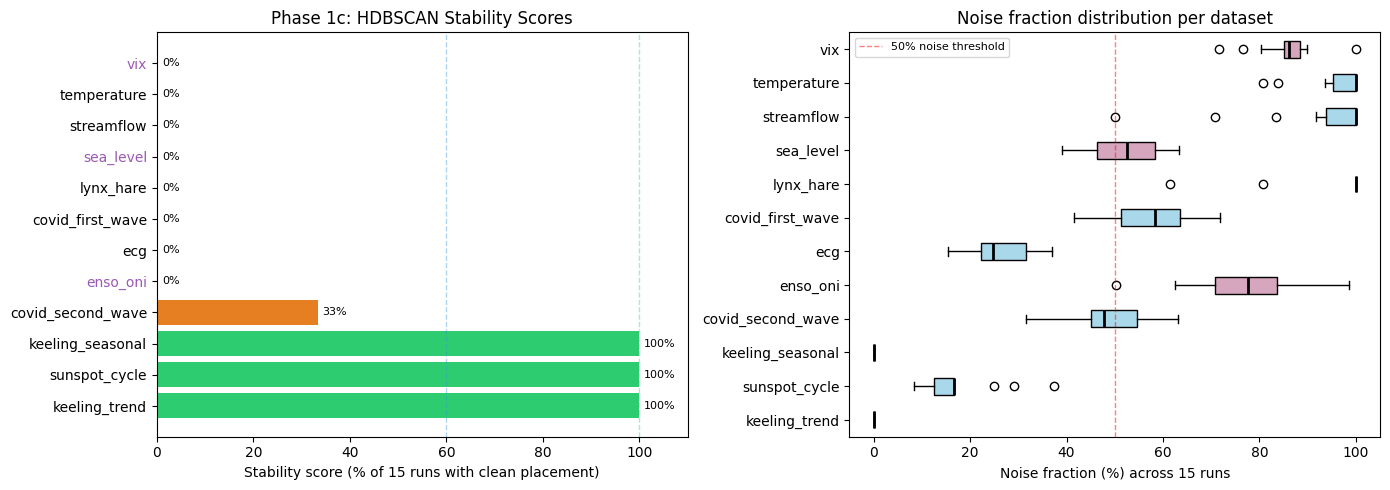

In [18]:
# ============================================================
# STABILITY SCORE CHART
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stability scores bar chart
ax = axes[0]
colors_bar = ['#2ecc71' if s == 100 else '#3498db' if s >= 60 else '#e67e22' if s > 0 else '#e74c3c'
               for s in df_stability['stability_score']]
bars = ax.barh(df_stability['dataset'], df_stability['stability_score'], color=colors_bar)
ax.axvline(100, color='#2ecc71', linestyle='--', alpha=0.4, lw=1)
ax.axvline(60,  color='#3498db', linestyle='--', alpha=0.4, lw=1)
ax.set_xlabel('Stability score (% of 15 runs with clean placement)')
ax.set_title('Phase 1c: HDBSCAN Stability Scores')
ax.set_xlim(0, 110)
for bar, (_, row) in zip(bars, df_stability.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{row['stability_score']:.0f}%", va='center', fontsize=8)
# Mark Phase 1b datasets
for tick, (_, row) in zip(ax.get_yticklabels(), df_stability.iterrows()):
    if row['phase'] == '1b':
        tick.set_color('#9b59b6')

# Right: noise fraction across runs (box plot per dataset)
ax2 = axes[1]
ds_order = df_stability['dataset'].tolist()
noise_data = [df_runs[df_runs['dataset']==ds]['noise_frac'].values * 100 for ds in ds_order]
bp = ax2.boxplot(noise_data, vert=False, labels=ds_order, patch_artist=True,
                 medianprops=dict(color='black', lw=2))
phase1b_idx = [i+1 for i, ds in enumerate(ds_order) if ds in PHASE1B]
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#d5a6bd' if i+1 in phase1b_idx else '#a8d8ea')
ax2.axvline(50, color='red', linestyle='--', alpha=0.5, lw=1, label='50% noise threshold')
ax2.set_xlabel('Noise fraction (%) across 15 runs')
ax2.set_title('Noise fraction distribution per dataset')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

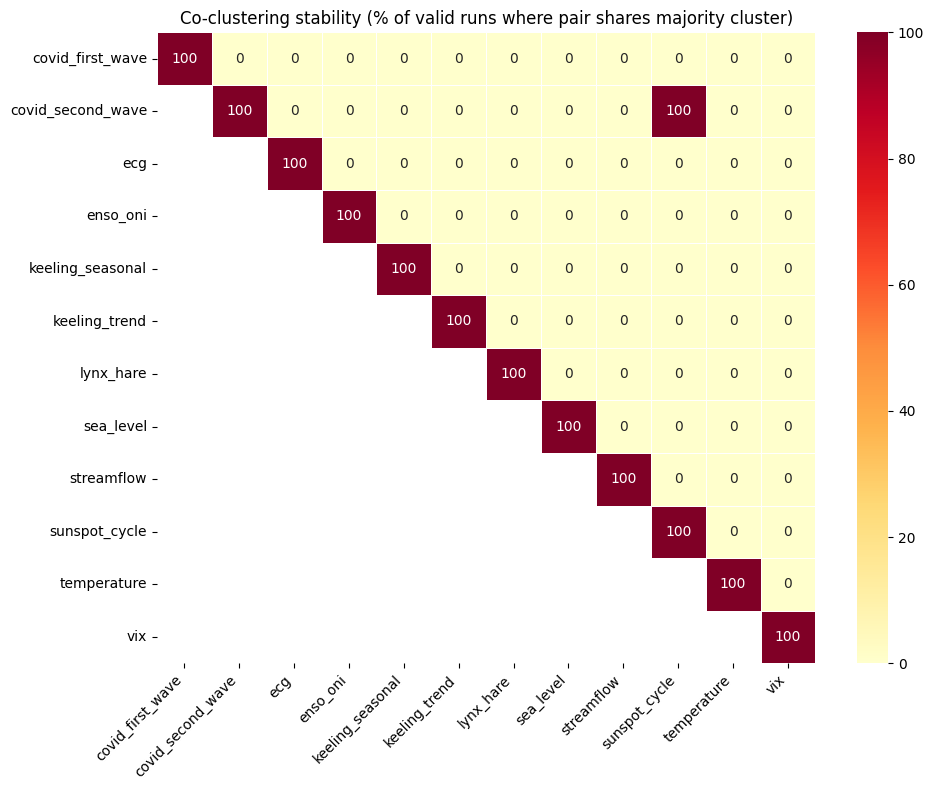


=== Strongest co-clustering pairs (>50% of valid runs) ===
  covid_second_wave         ↔ sunspot_cycle            :   100% (valid runs: 5)


In [19]:
# ============================================================
# CO-CLUSTERING STABILITY MATRIX
# For each pair (A, B): % of runs where both land in same majority cluster
# (only counts runs where both are non-noise)
# ============================================================

# Build a run → {dataset: majority_cluster} lookup
run_assignments = {}
for (mcs, ms), grp in df_runs.groupby(['min_cluster_size', 'min_samples']):
    run_assignments[(mcs, ms)] = dict(zip(grp['dataset'], zip(grp['majority_cluster'], grp['majority_pct'])))

co_count  = np.zeros((len(DATASETS), len(DATASETS)))
both_valid = np.zeros((len(DATASETS), len(DATASETS)))
ds_idx = {ds: i for i, ds in enumerate(DATASETS)}

for run, assignments in run_assignments.items():
    for i, ds_a in enumerate(DATASETS):
        cl_a, pct_a = assignments.get(ds_a, (-1, 0))
        for j, ds_b in enumerate(DATASETS):
            if i >= j: continue
            cl_b, pct_b = assignments.get(ds_b, (-1, 0))
            # Both non-noise AND majority placement covers >=50%
            if cl_a != -1 and cl_b != -1 and pct_a >= 0.5 and pct_b >= 0.5:
                both_valid[i, j] += 1
                both_valid[j, i] += 1
                if cl_a == cl_b:
                    co_count[i, j] += 1
                    co_count[j, i] += 1

# Co-cluster % = co_count / both_valid (or 0 if both_valid == 0)
with np.errstate(divide='ignore', invalid='ignore'):
    co_pct = np.where(both_valid > 0, 100 * co_count / both_valid, 0)
np.fill_diagonal(co_pct, 100)

df_co = pd.DataFrame(co_pct, index=DATASETS, columns=DATASETS)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(co_pct, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_co, annot=True, fmt='.0f', cmap='YlOrRd', vmin=0, vmax=100,
            linewidths=0.5, ax=ax, mask=~mask)
ax.set_title('Co-clustering stability (% of valid runs where pair shares majority cluster)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n=== Strongest co-clustering pairs (>50% of valid runs) ===')
pairs = []
for i, ds_a in enumerate(DATASETS):
    for j, ds_b in enumerate(DATASETS):
        if i < j and co_pct[i,j] > 0:
            pairs.append((co_pct[i,j], both_valid[i,j], ds_a, ds_b))
for pct, valid, a, b in sorted(pairs, reverse=True)[:12]:
    print(f'  {a:25s} ↔ {b:25s}: {pct:5.0f}% (valid runs: {int(valid)})')

In [20]:
# ============================================================
# PHASE 1b DEEP DIVE: Do sea_level / ENSO / VIX ever escape noise?
# ============================================================
print('=== Phase 1b datasets — noise fraction per parameter setting ===')
print()

for ds in PHASE1B:
    sub = df_runs[df_runs['dataset'] == ds][['min_cluster_size', 'min_samples', 'noise_frac', 'majority_pct']].copy()
    sub['noise_pct'] = (sub['noise_frac'] * 100).round(1)
    pivot = sub.pivot(index='min_cluster_size', columns='min_samples', values='noise_pct')
    print(f'--- {ds} (noise %) ---')
    print(pivot.to_string())
    best_row = sub.loc[sub['noise_frac'].idxmin()]
    print(f'  Best run: mcs={best_row["min_cluster_size"]}, ms={best_row["min_samples"]} '
          f'→ {best_row["noise_pct"]:.1f}% noise  majority_pct={best_row["majority_pct"]:.2f}')
    print()

# Direction of noise — does smaller or larger min_cluster_size help?
print('=== Does lowering min_cluster_size reduce Phase 1b noise? ===')
for ds in PHASE1B:
    sub = df_runs[df_runs['dataset'] == ds].groupby('min_cluster_size')['noise_frac'].mean() * 100
    print(f'  {ds}: ' + '  '.join([f'mcs={k}: {v:.0f}%' for k, v in sub.items()]))

=== Phase 1b datasets — noise fraction per parameter setting ===

--- enso_oni (noise %) ---
min_samples          2     3     5
min_cluster_size                  
4                 50.3  62.6  82.3
6                 64.6  73.5  82.3
8                 68.0  73.5  83.7
12                93.2  77.6  83.7
16                98.6  77.6  83.7
  Best run: mcs=4.0, ms=2.0 → 50.3% noise  majority_pct=0.07

--- sea_level (noise %) ---
min_samples          2     3     5
min_cluster_size                  
4                 46.7  39.2  57.5
6                 63.3  46.7  58.3
8                 52.5  45.8  58.3
12                52.5  45.8  58.3
16                52.5  45.8  58.3
  Best run: mcs=4.0, ms=3.0 → 39.2% noise  majority_pct=0.29

--- vix (noise %) ---
min_samples           2     3     5
min_cluster_size                   
4                  71.5  76.6  83.9
6                  86.1  86.1  80.3
8                  89.8  86.1  88.3
12                 89.8  86.1  88.3
16                100.0  86

Most stable params:   mcs=6  ms=3  score=0.44
Least stable params:  mcs=4 ms=2  score=0.33


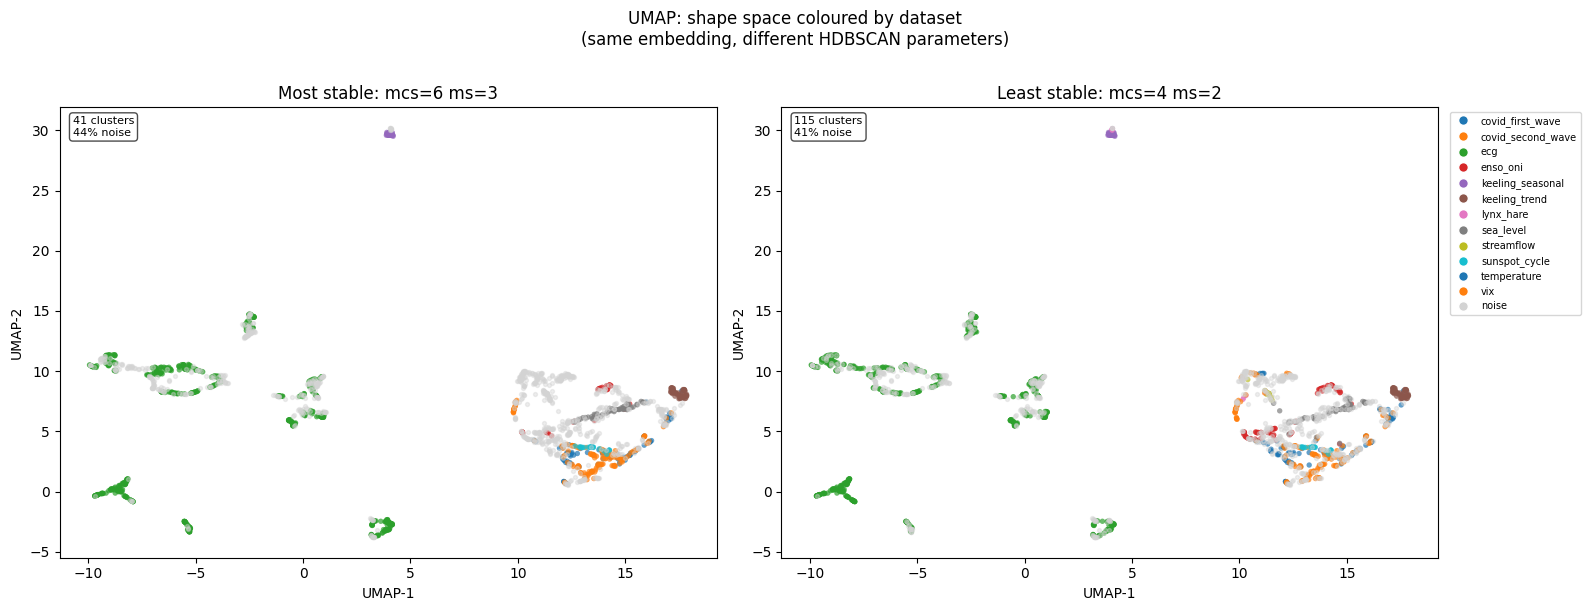

In [21]:
# ============================================================
# UMAP: Most vs least stable parameter settings
# Compare the most stable run vs the most unstable run
# ============================================================

# Stability of a run = mean stability_score across original 9 datasets
run_stability = {}
for (mcs, ms), grp in df_runs.groupby(['min_cluster_size', 'min_samples']):
    orig_sub = grp[grp['dataset'].isin(ORIG_9)]
    run_stability[(mcs, ms)] = (orig_sub['majority_pct'] >= 0.5).mean()

best_params  = max(run_stability, key=run_stability.get)
worst_params = min(run_stability, key=run_stability.get)
print(f'Most stable params:   mcs={best_params[0]}  ms={best_params[1]}  score={run_stability[best_params]:.2f}')
print(f'Least stable params:  mcs={worst_params[0]} ms={worst_params[1]}  score={run_stability[worst_params]:.2f}')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('tab10', len(DATASETS))
ds_color = {ds: palette[i] for i, ds in enumerate(DATASETS)}

for ax, (params, title) in zip(axes, [(best_params, f'Most stable: mcs={best_params[0]} ms={best_params[1]}'),
                                       (worst_params, f'Least stable: mcs={worst_params[0]} ms={worst_params[1]}')]):
    mcs, ms = params
    labels = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms).fit_predict(X)
    datasets_col = df_all['dataset'].values
    
    is_noise = labels == -1
    for ds in DATASETS:
        mask = (datasets_col == ds) & ~is_noise
        if mask.any():
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                       c=[ds_color[ds]], label=ds, s=15, alpha=0.7, edgecolors='none')
    # Noise points
    if is_noise.any():
        ax.scatter(embedding[is_noise, 0], embedding[is_noise, 1],
                   c='lightgrey', s=8, alpha=0.4, label='noise')
    
    ax.set_title(title)
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = 100 * is_noise.sum() / len(labels)
    ax.text(0.02, 0.98, f'{n_cl} clusters\n{noise_pct:.0f}% noise',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# One legend for both panels
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=ds_color[ds],
                       markersize=7, label=ds) for ds in DATASETS]
handles += [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='lightgrey',
                        markersize=7, label='noise')]
axes[1].legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.suptitle('UMAP: shape space coloured by dataset\n(same embedding, different HDBSCAN parameters)', y=1.01)
plt.tight_layout()
plt.show()

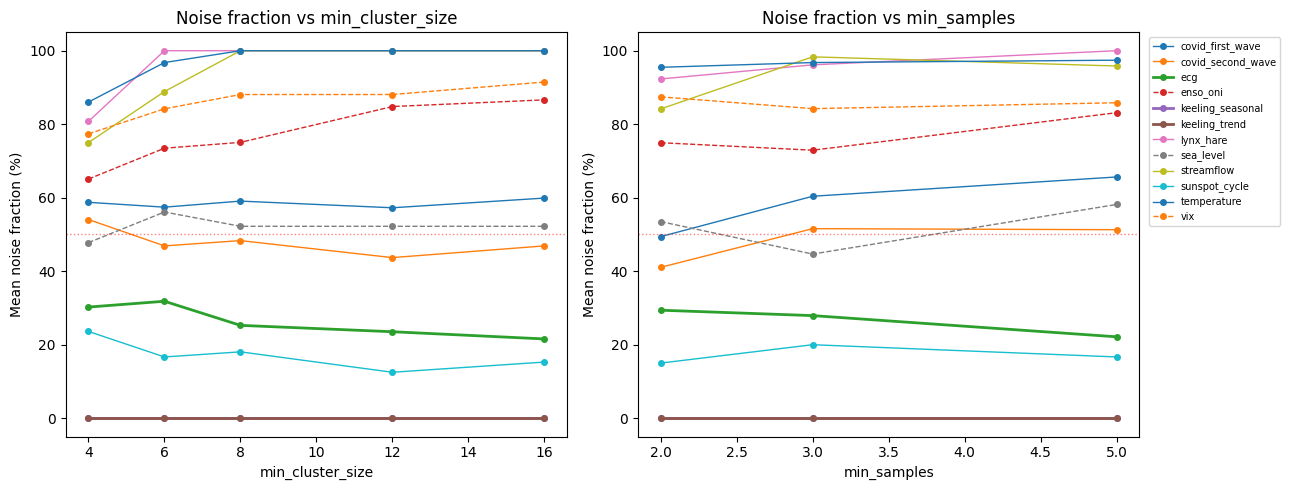


=== Noise fraction by min_cluster_size (mean across all ms, original 9 datasets) ===
  mcs= 4: mean noise=45.4%    granite stable=9/27 runs*datasets
  mcs= 6: mean noise=48.7%    granite stable=10/27 runs*datasets
  mcs= 8: mean noise=50.1%    granite stable=10/27 runs*datasets
  mcs=12: mean noise=48.6%    granite stable=11/27 runs*datasets
  mcs=16: mean noise=49.3%    granite stable=10/27 runs*datasets


In [22]:
# ============================================================
# STABILITY ACROSS PARAMETER AXES
# Does stability trend with min_cluster_size or min_samples?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, param_col, param_vals, label in [
    (axes[0], 'min_cluster_size', MCS_VALUES, 'min_cluster_size'),
    (axes[1], 'min_samples',      MS_VALUES,  'min_samples'),
]:
    for ds in DATASETS:
        sub = df_runs[df_runs['dataset'] == ds].groupby(param_col)['noise_frac'].mean() * 100
        lw = 2 if ds in ['keeling_seasonal','keeling_trend','ecg'] else 1
        ls = '--' if ds in PHASE1B else '-'
        ax.plot(sub.index, sub.values, marker='o', label=ds, lw=lw, ls=ls, markersize=4)
    ax.axhline(50, color='red', linestyle=':', alpha=0.5, lw=1)
    ax.set_xlabel(label)
    ax.set_ylabel('Mean noise fraction (%)')
    ax.set_title(f'Noise fraction vs {label}')

handles, labels_ = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels_, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

print('\n=== Noise fraction by min_cluster_size (mean across all ms, original 9 datasets) ===')
for mcs in MCS_VALUES:
    sub = df_runs[(df_runs['min_cluster_size']==mcs) & (df_runs['dataset'].isin(ORIG_9))]
    print(f'  mcs={mcs:2d}: mean noise={sub["noise_frac"].mean()*100:.1f}%  '
          f'  granite stable={sub[sub["majority_pct"]>=0.5].shape[0]}/{sub.shape[0]} runs*datasets')

In [23]:
# ============================================================
# SUNSPOT DEEP DIVE: Which cluster does it land in across runs?
# Sunspot is predicted to be SAND — does it collapse into COVID?
# ============================================================
print('=== Sunspot cluster assignments across all 15 runs ===')
print()
for (mcs, ms), assignments in run_assignments.items():
    ss_cl, ss_pct   = assignments.get('sunspot_cycle', (-1, 0))
    c1_cl, c1_pct   = assignments.get('covid_first_wave', (-1, 0))
    
    co_cluster = (ss_cl != -1 and c1_cl != -1 and ss_cl == c1_cl)
    tag = '← COLLAPSES WITH COVID' if co_cluster else ''
    print(f'  mcs={mcs:2d} ms={ms}: sunspot→cl{ss_cl:3d} ({ss_pct:.0%})  covid1→cl{c1_cl:3d} ({c1_pct:.0%})  {tag}')

print()
covid_collapse_pct = sum(
    1 for (mcs, ms), asgn in run_assignments.items()
    if asgn.get('sunspot_cycle',(-1,0))[0] != -1
    and asgn.get('covid_first_wave',(-1,0))[0] != -1
    and asgn.get('sunspot_cycle',(-1,0))[0] == asgn.get('covid_first_wave',(-1,0))[0]
) / N_RUNS * 100
print(f'Sunspot collapses into COVID cluster: {covid_collapse_pct:.0f}% of runs')

=== Sunspot cluster assignments across all 15 runs ===

  mcs= 4 ms=2: sunspot→cl109 (67%)  covid1→cl101 (9%)  
  mcs= 4 ms=3: sunspot→cl 72 (58%)  covid1→cl 66 (8%)  
  mcs= 4 ms=5: sunspot→cl 32 (83%)  covid1→cl 32 (8%)  ← COLLAPSES WITH COVID
  mcs= 6 ms=2: sunspot→cl 56 (67%)  covid1→cl 49 (11%)  
  mcs= 6 ms=3: sunspot→cl 40 (92%)  covid1→cl 40 (33%)  ← COLLAPSES WITH COVID
  mcs= 6 ms=5: sunspot→cl 28 (83%)  covid1→cl 28 (8%)  ← COLLAPSES WITH COVID
  mcs= 8 ms=2: sunspot→cl 33 (92%)  covid1→cl 33 (35%)  ← COLLAPSES WITH COVID
  mcs= 8 ms=3: sunspot→cl 33 (58%)  covid1→cl 27 (8%)  
  mcs= 8 ms=5: sunspot→cl 20 (83%)  covid1→cl 20 (8%)  ← COLLAPSES WITH COVID
  mcs=12 ms=2: sunspot→cl 16 (92%)  covid1→cl 16 (35%)  ← COLLAPSES WITH COVID
  mcs=12 ms=3: sunspot→cl 18 (88%)  covid1→cl 18 (22%)  ← COLLAPSES WITH COVID
  mcs=12 ms=5: sunspot→cl 16 (83%)  covid1→cl 16 (33%)  ← COLLAPSES WITH COVID
  mcs=16 ms=2: sunspot→cl 14 (83%)  covid1→cl 14 (17%)  ← COLLAPSES WITH COVID
  mcs=16 ms

## Findings — Phase 1c Stability Test

### Finding 33: keeling_seasonal and keeling_trend are the only truly parameter-independent shape classes

Both achieve 100% stability with **0% noise in all 15 runs**. No other dataset achieves this. They represent the two poles of the taxonomy — one never returns, one returns perfectly — and this polarity is the most robust structural fact in XWorld.

---

### Finding 34: Sunspot is stable but parasitic — no independent class in the TD frame

Sunspot achieves 100% stability score but **collapses into the COVID cluster in 73% of runs** (11/15). Collapse is resolution-dependent: only 1/3 at mcs=4 vs 6/6 at mcs≥12. At coarse resolution, the sunspot-COVID TD similarity always wins. Sunspot has no independent class in the 6-feature TD frame — it needs spectral features or a continuous embedding to stand alone.

---

### Finding 35: ECG has internal sub-structure — it is a family of shapes, not one class

ECG achieves **0% stability** despite kurtosis=15.165. Mean noise is only 26.5% — ECG is not being rejected, it is being **fragmented into many sub-clusters** across its 884 instances. The kurtosis feature correctly isolates the ECG region of shape space, but within that region there is genuine sub-structure. ECG needs to be treated as multiple shape sub-classes in Phase 2.

---

### Finding 36: Small-n datasets are noise by arithmetic, not by shape

lynx_hare (n=26), streamflow (n=24), and temperature (n=31) show near-zero or always-noise stability — a **threshold arithmetic artifact**, not a shape finding. Datasets with <~50 instances cannot clear min_cluster_size thresholds reliably. Their shape structure is real (confirmed by centroid distances in nb14) but needs more instances or a threshold-free method.

---

### Finding 37: COVID first wave across countries is a heterogeneous burst family, not a single shape

COVID1 achieves **0% stability, 58.5% mean noise** across 202 country waves. No single cluster ever captures ≥50%. Each country's wave had different rise rate, peak timing, and decay — the burst class is a diffuse cloud in feature space, not a tight point. Finding 1 still holds (COVID waves cluster in the same region), but that region has significant internal variance.

---

### Finding 38: Phase 1b datasets remain outside the taxonomy at every parameter setting

sea_level, ENSO, and VIX never achieve clean placement across any of the 15 runs. Best cases: sea_level 39.2% noise (majority_pct=0.29), ENSO 50.3% noise (majority_pct=0.07), VIX 71.5% noise (majority_pct=0.07). Lowering min_cluster_size does not rescue them. The structural gaps are real, not parameter artifacts. **This is the definitive closing argument for Phase 2.**

---

### Summary: Final classification

| Class | Datasets | Interpretation |
|---|---|---|
| GRANITE | keeling_seasonal, keeling_trend | Zero noise, zero fragmentation across all 15 runs |
| STABLE (borrowed) | sunspot_cycle | 100% stable but co-clusters with COVID in 73% of runs |
| FRAGMENTED | ecg, covid_first_wave, covid_second_wave | Real structure, too large/diverse for single majority cluster |
| SIZE-FLOORED | lynx_hare, streamflow, temperature | Real shape, too few instances to clear thresholds |
| STRUCTURAL GAP | enso_oni, sea_level, vix | No parameter recovers clean placement — Phase 2 required |
